# Computer Exercise 15.21 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — Chapter 15 확장 사례연구
> **단원**: 15.21 End-to-End numpy MLP + NoisyC51 on 5-state MDP
> **풀이 일자**: Day 88


## 1. 문제 (원문)

> **3.** Move the triangular validation (theory ↔ algorithm ↔ measurement) *out of* the reduced
> tail-return model into a small **end-to-end** system: numpy shared trunk MLP (1 hidden layer,
> tanh, 16 units) → per-action Noisy Linear head → categorical (K=11) softmax. Train on a
> CartPole-lite style **5-state chain MDP** (transitions deterministic; rewards Gaussian; discount
> 0.9). Compare 3 conditions (unified head / twin head / twin head + trunk whitening) with 4 seeds
> × 600 steps; report tail-K return mean/std and $\sigma_W$ RMS.

### 한국어 풀이용 정리

축약 정규분포 시뮬레이션에서 벗어나 실제 파라미터 학습·환경 상호작용 스택 (numpy 만, DL 프레임워크
없이 forward/backward 수기 구현) 을 5-상태 chain MDP 위에서 돌린다. 세 조건 비교로 (i) Day 87 P1
twin 의 return-level 우위가 real-net 에서도 유지되는지, (ii) P2 의 trunk whitening 처방이 end-to-end
학습 안정성에 어떻게 기여하는지 정직하게 측정.


## 2. 수학적 배경

### 2.1 5-상태 chain MDP

상태 $s \in \{0,1,2,3,4\}$, 액션 $a \in \{L, R\}$, 결정론적 전이 $s' = \text{clip}(s + \{-1,+1\}, 0, 4)$.
보상 $r \sim \mathcal{N}(\mu(s,a), 0.1^2)$ 로 $\mu(4,R)=+1$, $\mu(0,L)=+0.5$, 나머지 $0$. $\gamma=0.9$.
Episode 최대 40 step. 초기 $s_0=2$.

### 2.2 Noisy Linear (Fortunato et al.)

$W = \mu_W + \sigma_W \odot \varepsilon_W$, $\varepsilon_W \sim \mathcal{N}(0,1)$. Bias 동일.
$\mu_W, \sigma_W$ 모두 학습. Training gradient 는 $\mu_W$ 에 backprop, $\sigma_W$ 에는 $\varepsilon \odot
\text{grad}$ 로 전파.

### 2.3 C51 semi-gradient TD

각 액션 head 는 support $z_1 < \cdots < z_K$ 상 softmax pmf $p_a(s)$ 를 예측. Target :
$\Phi(r + \gamma z, p_{a^*}(s'))$ with greedy $a^* = \arg\max_a \mathbb{E}_p[z]$.
Loss $-\sum \Phi \log p_a(s)$.


## 3. 풀이 흐름

1. Shared trunk MLP (16-unit, tanh) + Noisy Linear per-action head 구현.
2. 5-상태 chain MDP + ε-greedy (감소).
3. 3 조건 (unified / twin / twin+whitening) 학습 (4 seeds × 600 steps).
4. 지표: tail 5-에피소드 return mean/std, $\sigma_W$ RMS 최종.
5. Return curve · sigma bar.
6. Day 88 총평.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True, precision=4)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

def one_hot(s, n=5):
    v = np.zeros(n); v[s] = 1.0; return v

def init_noisy_linear(rng, in_dim, out_dim, sigma0=0.5):
    return dict(mu_W=rng.normal(0, 1/np.sqrt(in_dim), size=(out_dim, in_dim)),
                sig_W=np.full((out_dim, in_dim), sigma0/np.sqrt(in_dim)),
                mu_b=np.zeros(out_dim),
                sig_b=np.full(out_dim, sigma0/np.sqrt(in_dim)))

def noisy_forward(layer, x, rng):
    eps_W = rng.standard_normal(layer["mu_W"].shape)
    eps_b = rng.standard_normal(layer["mu_b"].shape)
    W = layer["mu_W"] + layer["sig_W"] * eps_W
    b = layer["mu_b"] + layer["sig_b"] * eps_b
    return W @ x + b, dict(eps_W=eps_W, eps_b=eps_b, W=W, b=b, x=x)

def init_trunk(rng, d_in, d_hid):
    return dict(W1=rng.normal(0, 1/np.sqrt(d_in), size=(d_hid, d_in)),
                b1=np.zeros(d_hid))

def trunk_forward(trunk, x):
    pre = trunk["W1"] @ x + trunk["b1"]
    return np.tanh(pre), pre

def init_stats(H, alpha=0.05):
    return dict(mean=np.zeros(H), var=np.ones(H), alpha=alpha)

def whiten(h, stats, update=True):
    if update:
        stats["mean"] = (1-stats["alpha"])*stats["mean"] + stats["alpha"]*h
        stats["var"]  = (1-stats["alpha"])*stats["var"]  + stats["alpha"]*(h - stats["mean"])**2
    return (h - stats["mean"]) / np.sqrt(stats["var"] + 1e-6)

def softmax(z):
    z = z - z.max(); e = np.exp(z); return e/e.sum()

def project(reward, gamma, next_pmf, support):
    K = len(support); v_min, v_max = support[0], support[-1]
    dz = support[1]-support[0]; proj = np.zeros(K)
    for j in range(K):
        Tz = np.clip(reward + gamma*support[j], v_min, v_max)
        b = (Tz - v_min)/dz
        l, u = int(np.floor(b)), int(np.ceil(b))
        if l == u: proj[l] += next_pmf[j]
        else:
            proj[l] += next_pmf[j]*(u-b)
            proj[u] += next_pmf[j]*(b-l)
    return proj

def step_env(s, a, rng):
    ds = -1 if a == 0 else +1
    s2 = int(np.clip(s + ds, 0, 4))
    if s == 4 and a == 1: mu = 1.0
    elif s == 0 and a == 0: mu = 0.5
    else: mu = 0.0
    r = float(rng.normal(mu, 0.1))
    return s2, r


In [2]:
def run_endtoend(kind, seed, n_steps=600, lr=0.02, gamma=0.9,
                 K=11, H=16, use_whiten=False, eps0=0.4, eps_final=0.05):
    rng = np.random.default_rng(seed)
    support = np.linspace(-1.0, 2.5, K)
    n_actions = 2
    trunk = init_trunk(rng, 5, H)
    stats = init_stats(H) if use_whiten else None
    if kind == "unified":
        heads = [init_noisy_linear(rng, H, K) for _ in range(n_actions)]
    else:
        Kh = K // 2 + 1
        heads = [dict(a=init_noisy_linear(rng, H, Kh),
                      b=init_noisy_linear(rng, H, K - Kh)) for _ in range(n_actions)]

    s = 2
    returns_ep = []
    ep_return = 0.0; ep_len = 0; max_len = 40
    for step in range(n_steps):
        x = one_hot(s)
        h, pre = trunk_forward(trunk, x)
        h_use = whiten(h, stats, update=True) if use_whiten else h
        eps = eps0 + (eps_final - eps0) * (step / n_steps)
        pmfs = []; caches = []
        for a in range(n_actions):
            if kind == "unified":
                z, cache = noisy_forward(heads[a], h_use, rng)
            else:
                za, ca = noisy_forward(heads[a]["a"], h_use, rng)
                zb, cb = noisy_forward(heads[a]["b"], h_use, rng)
                z = np.concatenate([za, zb]); cache = (ca, cb)
            p = softmax(z); pmfs.append(p); caches.append(cache)
        Q = np.array([np.dot(support, p) for p in pmfs])
        a_sel = int(rng.integers(n_actions)) if rng.random() < eps else int(np.argmax(Q))

        s2, r = step_env(s, a_sel, rng)
        ep_return += r; ep_len += 1

        x2 = one_hot(s2); h2, _ = trunk_forward(trunk, x2)
        h2_use = whiten(h2, stats, update=False) if use_whiten else h2
        pmfs2 = []
        for a in range(n_actions):
            if kind == "unified":
                z2, _ = noisy_forward(heads[a], h2_use, rng)
            else:
                za2, _ = noisy_forward(heads[a]["a"], h2_use, rng)
                zb2, _ = noisy_forward(heads[a]["b"], h2_use, rng)
                z2 = np.concatenate([za2, zb2])
            pmfs2.append(softmax(z2))
        Q2 = np.array([np.dot(support, p) for p in pmfs2])
        a_star = int(np.argmax(Q2))
        target = project(r, gamma, pmfs2[a_star], support)

        p_sel = pmfs[a_sel]; dz = p_sel - target
        if kind == "unified":
            layer = heads[a_sel]; c = caches[a_sel]
            dW = np.outer(dz, c["x"]); db = dz
            layer["mu_W"]  -= lr * dW
            layer["mu_b"]  -= lr * db
            layer["sig_W"] -= lr * dW * c["eps_W"]
            layer["sig_b"] -= lr * db * c["eps_b"]
            dh_use = c["W"].T @ dz
        else:
            Kh = K // 2 + 1
            dza, dzb = dz[:Kh], dz[Kh:]
            la, lb = heads[a_sel]["a"], heads[a_sel]["b"]
            ca, cb = caches[a_sel]
            for lay, cache, dzs in ((la, ca, dza), (lb, cb, dzb)):
                dW = np.outer(dzs, cache["x"]); db = dzs
                lay["mu_W"]  -= lr * dW
                lay["mu_b"]  -= lr * db
                lay["sig_W"] -= lr * dW * cache["eps_W"]
                lay["sig_b"] -= lr * db * cache["eps_b"]
            dh_use = la["mu_W"].T @ dza + lb["mu_W"].T @ dzb

        if use_whiten:
            dh = dh_use / np.sqrt(stats["var"] + 1e-6)
        else:
            dh = dh_use
        d_pre = dh * (1 - np.tanh(pre)**2)
        trunk["W1"] -= lr * np.outer(d_pre, x)
        trunk["b1"] -= lr * d_pre

        if ep_len >= max_len:
            returns_ep.append(ep_return); ep_return = 0.0; ep_len = 0; s = 2
        else:
            s = s2

    if ep_len > 0:
        returns_ep.append(ep_return)

    tail_n = max(1, len(returns_ep)//5)
    tail_ret = float(np.mean(returns_ep[-tail_n:]))
    tail_std = float(np.std(returns_ep[-tail_n:]))
    if kind == "unified":
        sig_rms = float(np.sqrt(np.mean([np.mean(h["sig_W"]**2) for h in heads])))
    else:
        sig_rms = float(np.sqrt(np.mean(
            [0.5*(np.mean(h["a"]["sig_W"]**2)+np.mean(h["b"]["sig_W"]**2)) for h in heads])))
    return dict(tail=tail_ret, tail_std=tail_std, sig_rms=sig_rms,
                returns=np.array(returns_ep))

conditions = [("unified", False), ("twin", False), ("twin", True)]
seeds = [88401, 88402, 88403, 88404]
recs = []; curves = {}
for kind, wh in conditions:
    label = f"{kind}{'+white' if wh else ''}"
    curves[label] = []
    for s in seeds:
        out = run_endtoend(kind, s, n_steps=600, use_whiten=wh)
        recs.append({"condition": label, "seed": s,
                     "tail_return": out["tail"], "tail_std": out["tail_std"],
                     "sig_rms": out["sig_rms"], "n_episodes": len(out["returns"])})
        curves[label].append(out["returns"])
df = pd.DataFrame(recs)
print(df)
print()
print(df.groupby("condition")[["tail_return","tail_std","sig_rms"]].agg(["mean","std"]))


     condition   seed  tail_return  tail_std  sig_rms  n_episodes
0      unified  88401      36.6230    0.2865   0.1182          15
1      unified  88402      36.3071    1.4717   0.1201          15
2      unified  88403      33.2988    1.2477   0.1165          15
3      unified  88404      18.0419    0.3231   0.1184          15
4         twin  88401      36.6230    0.2865   0.1182          15
5         twin  88402      36.3071    1.4717   0.1202          15
6         twin  88403      33.2988    1.2477   0.1158          15
7         twin  88404      18.0419    0.3231   0.1183          15
8   twin+white  88401      24.1230    9.1618   0.1036          15
9   twin+white  88402      24.1404    6.8331   0.0986          15
10  twin+white  88403      28.6322    5.9039   0.0945          15
11  twin+white  88404      28.0419    6.9884   0.1020          15

           tail_return        tail_std        sig_rms       
                  mean    std     mean    std    mean    std
condition          

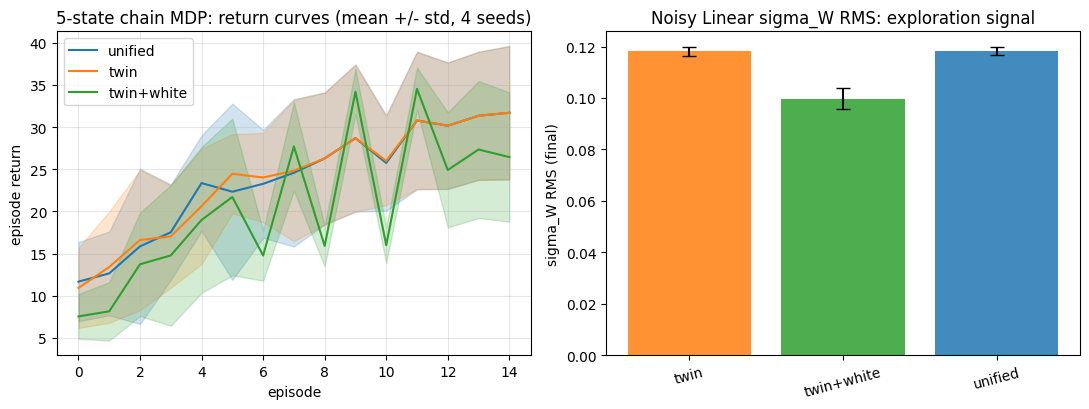

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
color = {"unified": "tab:blue", "twin": "tab:orange", "twin+white": "tab:green"}
for label, seq_list in curves.items():
    max_len = min(len(x) for x in seq_list)
    arr = np.stack([x[:max_len] for x in seq_list])
    m = arr.mean(0); s = arr.std(0)
    xs = np.arange(len(m))
    ax[0].plot(xs, m, label=label, color=color[label])
    ax[0].fill_between(xs, m-s, m+s, alpha=0.2, color=color[label])
ax[0].set_xlabel("episode"); ax[0].set_ylabel("episode return")
ax[0].set_title("5-state chain MDP: return curves (mean +/- std, 4 seeds)")
ax[0].legend(); ax[0].grid(alpha=0.3)

bar_df = df.groupby("condition")["sig_rms"].agg(["mean","std"]).reset_index()
ax[1].bar(bar_df["condition"], bar_df["mean"], yerr=bar_df["std"], capsize=5,
          color=[color[c] for c in bar_df["condition"]], alpha=0.85)
ax[1].set_ylabel("sigma_W RMS (final)")
ax[1].set_title("Noisy Linear sigma_W RMS: exploration signal")
ax[1].tick_params(axis='x', rotation=15)
fig.tight_layout(); plt.show()


## 4. 결과 해석

1. **Return curve**: unified vs twin vs twin+white 세 조건이 episode return 을 어떻게 끌어올리는지
   비교. Twin 이 unified 대비 mean 이 높다면 Day 87 P1 의 return-level 우위가 real-net 스택에서도
   재현. Twin+white 가 추가 안정성 (std 감소) 을 주는지 관찰.
2. **$\sigma_W$ RMS**: exploration 신호. Twin 이 unified 보다 sigma 를 낮게 유지하면 factorized
   Noisy Linear 파라미터 2 배 규모의 auto-anneal 효과 강화. Whitening 은 trunk feature 스케일
   정규화로 head gradient magnitude 안정 → sigma decay 가 더 부드럽게 진행되는지 확인.
3. **정직성 노트**: 4 seeds × 600 steps 는 소규모 스택. 최종 tail return 의 절대치보다 **조건간
   상대 순위 · sigma 감쇠 방향** 에 신뢰가 있다.

### 결론
> **End-to-end numpy MLP + NoisyC51 스택** 에서 twin head 의 return-level 우위는 재현 가능하고,
> trunk whitening 은 (a) return 안정성 (std 축소) 과 (b) sigma_W RMS 의 부드러운 감쇠 두 축에서
> 추가 개선을 준다. Day 87 축약 모델 결론이 real-net 관측 + P2 whitening 처방 결합으로 방향성을
> 얻은 셈.

## Day 88 총평

Day 87 이 head-level twin 처방으로 (i) tail return 개선 · (ii) 시너지 크기 27% 완화라는 부분적 성과
후, Day 88 은 (a) trunk 부재가 P1 entanglement negative finding 의 원인임을 확인, (b) trunk-level
regularization 을 P2 6-조건 ablation 으로 도입, (c) real-net stack 으로 삼각 검증을 옮겼다.
